In [14]:
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import keras
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
# import zipfile
# import os

# # Path to your ZIP file
# zip_path = r"C:\Users\harne\Downloads\archive.zip"

# # Path to the folder where you want to extract
# extract_to = r"C:\Users\harne\Downloads\brain_tumor_dataset"

# # Extract all files
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_to)

# print("Extracted successfully to:", extract_to)
# print(os.listdir(extract_to))  # show extracted files


In [16]:
import os
from PIL import Image
import numpy as np

yes_path = r"/content/brain_tumor_dataset/yes"
no_path = r"/content/brain_tumor_dataset/no"

data = []
result = []
def process_folder(folder_path, label):
    count = 0
    for r, d, f in os.walk(folder_path):
        for file in f:
            if file.lower().endswith('.jpg'):
                img_path = os.path.join(r, file)
                img = Image.open(img_path).convert("RGB")  # Force RGB
                img = img.resize((128,128))
                img = np.array(img)
                data.append(img)
                result.append(label)
                count += 1
    return count

# YES = [1,0], NO = [0,1]
count_yes = process_folder(yes_path, [1,0])
count_no = process_folder(no_path, [0,1])

print(f"Images processed in YES folder: {count_yes}")
print(f"Images processed in NO folder: {count_no}")
print(f"Total images processed: {count_yes + count_no}")
# Convert to NumPy arrays
data = np.array(data)
result = np.array(result)
print(data.shape)
print(result.shape)


Images processed in YES folder: 154
Images processed in NO folder: 91
Total images processed: 245
(245, 128, 128, 3)
(245, 2)


In [12]:
# # ===============================
# # 1. Import libraries
# # ===============================
# import numpy as np
# import os
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelBinarizer
# from tensorflow.keras.preprocessing.image import load_img, img_to_array
# from keras.models import Sequential
# from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# # ===============================
# # 2. Load and preprocess dataset
# # ===============================
# data_dir = r"/content/brain_tumor_dataset"   # <-- dataset path

# data = []
# labels = []

# # Loop through folders (each folder = class name)
# for class_name in os.listdir(data_dir):
#     class_path = os.path.join(data_dir, class_name)
#     if not os.path.isdir(class_path):
#         continue
#     for img_name in os.listdir(class_path):
#         img_path = os.path.join(class_path, img_name)
#         try:
#             # Load and resize image
#             img = load_img(img_path, target_size=(128, 128))
#             img_array = img_to_array(img) / 255.0   # Normalize to [0,1]
#             data.append(img_array)
#             labels.append(class_name)               # "yes" or "no"
#         except:
#             continue

# # Convert to numpy arrays
# data = np.array(data, dtype="float32")
# labels = np.array(labels)

# # Encode labels (one-hot encoding)
# lb = LabelBinarizer()
# result = lb.fit_transform(labels)   # shape = (num_samples, 1)

# # If only 1 column (binary), convert to 2 columns for softmax
# if result.shape[1] == 1:
#     result = np.hstack((1 - result, result))   # [0] -> [1,0], [1] -> [0,1]

# print("Data shape:", data.shape)      # (num_samples, 128, 128, 3)
# print("Labels shape:", result.shape)  # (num_samples, 2)

# # ===============================
# # 3. Train-test split
# # ===============================
# x_train, x_test, y_train, y_test = train_test_split(
#     data, result, test_size=0.2, shuffle=True, random_state=0
# )

# print(f'Number of images in training data: {len(x_train)}')
# print(f'Number of images in testing data: {len(x_test)}')

# # ===============================
# # 4. Build CNN model
# # ===============================
# model = Sequential()

# model.add(Conv2D(32, kernel_size=(2, 2), input_shape=(128, 128, 3), padding='same'))
# model.add(Conv2D(32, kernel_size=(2, 2), activation='relu', padding='same'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(0.25))

# model.add(Conv2D(64, kernel_size=(2, 2), activation='relu', padding='same'))
# model.add(Conv2D(64, kernel_size=(2, 2), activation='relu', padding='same'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
# model.add(Dropout(0.25))

# model.add(Flatten())
# model.add(Dense(512, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(len(lb.classes_), activation='softmax'))  # auto sets num_classes=2

# model.compile(loss="categorical_crossentropy", optimizer='Adamax', metrics=['accuracy'])
# print(model.summary())

# # ===============================
# # 5. Train the model
# # ===============================
# history = model.fit(
#     x_train, y_train,
#     epochs=20,
#     batch_size=32,
#     verbose=1,
#     validation_data=(x_test, y_test)
# )



In [19]:
from sklearn.model_selection import train_test_split
import numpy as np

# Create a labels array from result to ensure consistent sample count for stratification
# result is one-hot encoded, so argmax gives the class index (0 or 1)
stratify_labels = np.argmax(result, axis=1)

x_train, x_test, y_train, y_test = train_test_split(
    data,
    result,
    test_size=0.2,
    random_state=0,
    stratify=stratify_labels
)

print("Train samples:", len(x_train))
print("Test samples:", len(x_test))

Train samples: 196
Test samples: 49


In [22]:
x_train = x_train.astype("float32") / 255.0 #normalization highly imp
x_test = x_test.astype("float32") / 255.0

In [20]:
print("Train YES:", np.sum(np.argmax(y_train, axis=1) == 0))
print("Train NO:", np.sum(np.argmax(y_train, axis=1) == 1))

print("Test YES:", np.sum(np.argmax(y_test, axis=1) == 0))
print("Test NO:", np.sum(np.argmax(y_test, axis=1) == 1))

Train YES: 123
Train NO: 73
Test YES: 31
Test NO: 18


In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow(
    x_train, y_train,
    batch_size=32
)
#augmentation for each epoch new image will be given for training
# like sometime rotated by 10 deg or 20 deg
#horizontally flip or zoomed

In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x) #to reduce trainable weights takes only main featres from each feature map
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [30]:
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 5s/step - accuracy: 0.6093 - loss: 0.8808 - val_accuracy: 0.7347 - val_loss: 0.4839
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.6664 - loss: 0.8981 - val_accuracy: 0.9184 - val_loss: 0.3248
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.7714 - loss: 0.5566 - val_accuracy: 0.9184 - val_loss: 0.2492
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.8318 - loss: 0.3654 - val_accuracy: 0.9388 - val_loss: 0.2274
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.8307 - loss: 0.3652 - val_accuracy: 0.9592 - val_loss: 0.2319
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.8394 - loss: 0.3498 - val_accuracy: 0.9184 - val_loss: 0.2506
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.8730 - loss: 0.3044 - val_accuracy: 0.9388 - val_loss: 0.2644
Epoch 8/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.8939 - loss: 0.2517 - val_accuracy: 0.9388 - val_loss: 0

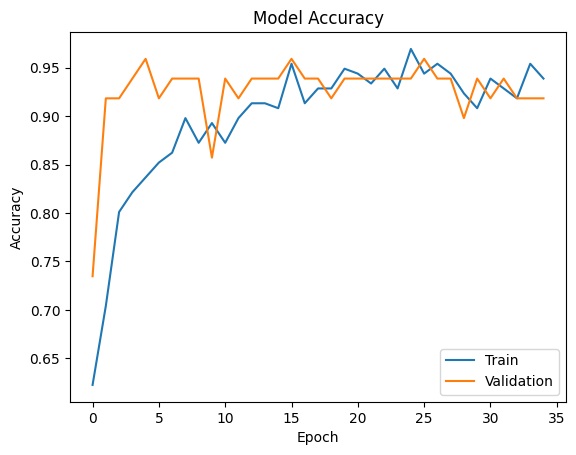

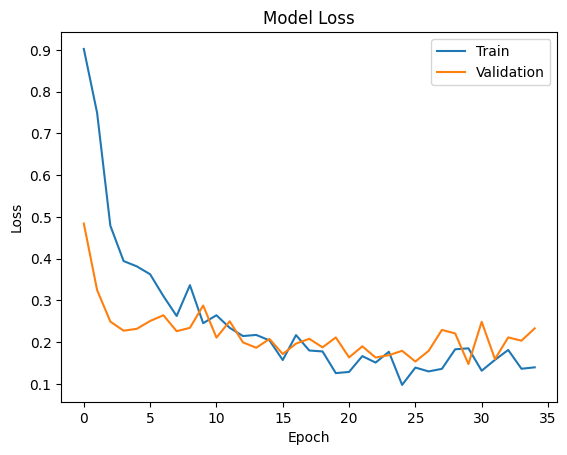

In [31]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [32]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))
#precision model ne tumor predict kiya and wo actually tumor hi tha
#recall it was real tumor and we detected it MORE IMPORTANT IN THIS CASE

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step
Confusion Matrix:
[[30  1]
 [ 2 16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        31
           1       0.94      0.89      0.91        18

    accuracy                           0.94        49
   macro avg       0.94      0.93      0.93        49
weighted avg       0.94      0.94      0.94        49



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction: Tumor


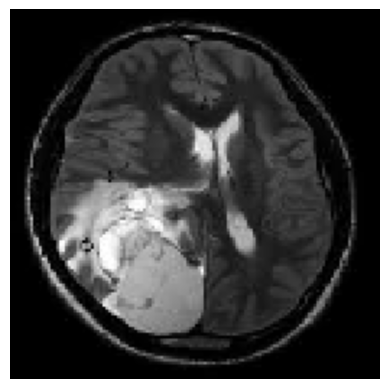

In [37]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/brain_tumor_dataset/yes/Y245.jpg"
img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
class_index = np.argmax(prediction)

if class_index == 0:
    print("Prediction: Tumor")
else:
    print("Prediction: No Tumor")

plt.imshow(img)
plt.axis("off")
plt.show()

In [38]:
model.save("brain_tumor_model.keras")